# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

In [1]:
import pandas  as pd               #LECTURA, MANEJO Y TRANSFORMACIÓN DE DATAFRAMES.
import numpy   as np               #FUNCIONES MATEMÁTICAS RELEVANTES.
import matplotlib.pyplot as plt    #GRÁFICOS.
import seaborn as sns
from scipy.stats import pointbiserialr #importar función específica desde una librería y no toda la librería completa.
from scipy.stats import chi2_contingency


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
path = 'https://raw.githubusercontent.com/FithoGerardo/NovaRetailPlus-E-Commerce-Behavioral-Factors---Correlational-exploratory-analysis./refs/heads/main/data/novaretail_comportamiento_clientes_2024.csv'
df = pd.read_csv(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
df.head(5)


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


In [4]:
# Guardar copia
# df.to_csv('nova_behave_clients_2024.csv', index=False, encoding='utf-8')

In [5]:
# copia de plans, users y usage
dfc = df.copy() #dfc = df_copy

display(dfc.info())
display(dfc.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


None

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

In [40]:
display(dfc['edad'].describe()) # see age range [18 - 75]
dfc['edad'] = dfc['edad'].astype('int64') # from float to int
display(dfc['edad'].head(2))

,edad
count,15000.000000
mean,38.262400
std,11.492378
min,18.000000
25%,30.000000
50%,38.000000
75%,46.000000
max,75.000000


,edad
0,44
1,36


In [82]:
col_num = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes',
       'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual'] # identifying numeric columns
col_cat = dfc.select_dtypes(include = ['object']).columns # identifying categorical columns
col_bool = ['miembro_premium', 'abandono'] # identifying boolean columns
print('col_num:\n', col_num)
print('\ncol_cat:\n', col_cat)
print('\ncol_bool:\n', col_bool)

col_num:
 ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

col_cat:
 Index(['id_cliente', 'tipo_dispositivo', 'region'], dtype='object')

col_bool:
 ['miembro_premium', 'abandono']


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.

Se modificó `edad` de **float** a **int**

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

#### Explorar variables numéricas

In [56]:
# Estadísticas descriptivas de variables numéricas
display(dfc[col_num].describe(percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
display(dfc['ingreso_anual'].sum())

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
10%,23.000000,17284.414000,6.000000,0.000000,6.210000,2.700000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
90%,53.000000,42767.229000,14.000000,3.000000,34.321000,4.500000,84.080000
95%,58.000000,46534.497500,15.000000,3.000000,38.770000,4.800000,101.642500


np.float64(548912.7)

Diagnóstico inicial de variables numéricas

- `edad` [18 - 75]; median 38; Población adulta bien distribuida, sin sesgos extremos hacia jóvenes o adultos mayores.
- `nivel_ingreso` [\$8,000 - \$74,790.84]; mean \$30,019.70; std \$9,833.16; Clientes de diferentes capacidades económicas; no hay concentración extrema en un segmento.
- `visitas_mes` [1 - 25]; median 10; Mayoría de clientes visita la plataforma ~10 veces/mes; patrón predecible.
- `compras_mes` [0 - 8]; mean 1.20 (sesgada hacia compras bajas). 25% de clientes no compran (percentil 25 = 0); Esto marca dos segmentos: ***compradores activos vs. pasivos***.
- `gasto_publicidad_dirigida` [0 - 75.51]; distribución simétrica; Existe inversión diferenciada en publicidad; no todos los clientes reciben igual presupuesto.
- `satisfaccion` [1 - 5]; distribución simétrica; Clientes relativamente satisfechos (promedio superior a 3.5); sin extremos de insatisfacción masiva.
- `ingreso_anual` [0 - 244.69]; Suma total \$548,912.7; Muchos clientes sin ingresos; Sesgo positivo leve; std 34.48 muy alta respecto a la media (elevada dispersión); ~25% de clientes genera 0 ingresos (percentil 25 = 0); esto marca la principal segmentación del problema: ***clientes activos vs. inactivos***.

Recomendación: Considerar análisis segmentado (clientes con compras vs. sin compras) para correlaciones más claras

#### Explorar variables binarias

In [81]:
# Verificar que cada columna tenga únicamente dos valores posibles
display(dfc[col_bool].value_counts().sum()) # = 15,000
display(dfc[col_bool].value_counts())
display(dfc['abandono'].value_counts())
display(dfc[col_num + col_bool].describe(percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

np.int64(15000)

miembro_premium  abandono
0                0           10741
                 1            2170
1                0            1998
                 1              91
Name: count, dtype: int64

,count
abandono,
0,12739
1,2261


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual,miembro_premium,abandono
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180,0.139267,0.150733
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888,0.346236,0.357801
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
10%,23.000000,17284.414000,6.000000,0.000000,6.210000,2.700000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000,0.000000,0.000000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000,0.000000,0.000000
90%,53.000000,42767.229000,14.000000,3.000000,34.321000,4.500000,84.080000,1.000000,1.000000
95%,58.000000,46534.497500,15.000000,3.000000,38.770000,4.800000,101.642500,1.000000,1.000000


Diagnóstico inicial de variables binarias
- `abandono`
- - Activos 0: 12,739 (84.93%)
- - Inctivos 1: 2,261 (15.07%)

Potencial relación inversa con ingreso_anual (clientes que abandonen vs. que permanezcan).

- `miembro_premium`
- - Premium 1: 2,089 (13.93%)
- - No premium 0: 12,911 (86.07%)

Potencial relación con ingreso_anual.

- **Análisis cruzado**:

Categoría |----------- Count --| % del Total | Interpretación

No premium Activos:----10,741 | 71.60% --| Núcleo de clientes base

No premium Inactivos:---2,170 | 14.46% --| Riesgo: clientes base que se van

Premium Activos:--------1,998 | 13.32% --| Clientes de valor (retención alta)

Premium Inactivos:---------91 | 00.60% --| Riesgo bajo: retención premium muy alta

Hallazgo clave:

- Retención premium: (1,998 / 2,089) = 95.6%
- Retención base: (10,741 / 12,911) = 83.2%
- La suscripción premium correlaciona fuertemente con retención

---

**RECOMENDACIONES PARA ANÁLISIS**

1. Segmentación obligatoria:
- Clientes activos (compras_mes > 0) vs. inactivos
- Esto mejorará claridad de correlaciones

2. Variables listas para correlación:
- satisfaccion (sin ceros, varianza controlada)
- visitas_mes (distribución limpia)
- edad (rango simétrico)
- compras_mes, ingreso_anual (requieren tratamiento de ceros)

3. Relaciones esperadas a explorar:

- miembro_premium → ingreso_anual (correlación fuerte esperada)
- abandono → ingreso_anual (correlación negativa esperada)
- visitas_mes × compras_mes → ingreso_anual (patrón de engagement)

#### Explorar variables categóricas

In [119]:
# Verificar el número de valores únicos por variable categórica
display(dfc[col_cat].nunique(dropna=False))

,0
id_cliente,15000
tipo_dispositivo,3
region,4


In [120]:
# Explorar variables categóricas y cómo se distribuyen
print('-------value_counts()-------\n')
display(dfc['tipo_dispositivo'].value_counts())
display(dfc['region'].value_counts())
display(dfc[['tipo_dispositivo', 'region']].value_counts())
print('\n-------describe()-------\n')
display(dfc[col_cat].describe())

-------value_counts()-------



,count
tipo_dispositivo,
móvil,9818
escritorio,3720
tablet,1462


,count
region,
norte,4395
oeste,3810
sur,3726
este,3069


tipo_dispositivo  region
móvil             norte     2843
                  oeste     2489
                  sur       2483
                  este      2003
escritorio        norte     1125
                  oeste      935
                  sur        894
                  este       766
tablet            norte      427
                  oeste      386
                  sur        349
                  este       300
Name: count, dtype: int64


-------describe()-------



,id_cliente,tipo_dispositivo,region
count,15000,15000,15000
unique,15000,3,4
top,CL-114999,móvil,norte
freq,1,9818,4395


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo`
- móvil (9,818 / ~65%)
- escritorio (3,720 / ~25%)
- tablet (1,462 / ~10%)

Distribución claramente desbalanceada: el móvil domina. No requiere transformación, pero conviene considerar el desbalance al interpretar resultados por segmento.

- `region`
- norte (4,395 / ~29%)
- oeste (3,810 / ~25%)
- sur (3,726 / ~25%)
- este (3,069 / ~20%)

Distribución relativamente equilibrada entre regiones. No requiere transformación adicional.

---

**Análisis cruzado**:

La proporción entre dispositivos se mantiene consistente en todas las regiones (móvil siempre predomina ~65%), lo que sugiere que no hay una concentración geográfica atípica por tipo de dispositivo. No se detectan combinaciones vacías ni anomalías.

---
### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

In [139]:
def corr_analysis_num(data, cols, corr_method = 'pearson'):
  # Calcular matriz de correlación
  corr_matrix = data[cols].corr(method = corr_method)
  print("ANÁLISIS DE CORRELACIÓN. Variables numérica-numérica")
  print("----------------------------------------------------------")

  # Tabla
  print(f"MATRIZ DE CORRELACIONES - Method: {corr_method} ")
  display(corr_matrix)
  print("----------------------------------------------------------")

  # Heatmap
  plt.figure(figsize = (15,5), dpi = 140)
  sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
  plt.title(f"Heatmap - Coeficientes de correlación - Method: {corr_method}", fontsize = 20)
  plt.savefig(f"Heatmap - {corr_method}_method.png",dpi = 140)
  plt.show()

  # Scatterplot general, Pairplot o diagrama de pares
  # print("----------------------------------------------------------")
  # sns.pairplot(data[cols])
  # plt.title(f"Pairplot - Method: {corr_method}", fontsize = 20)
  # plt.savefig(f"Pairplot -  {corr_method}_method.png",dpi = 140)
  # plt.show()

ANÁLISIS DE CORRELACIÓN. Variables numérica-numérica
----------------------------------------------------------
MATRIZ DE CORRELACIONES - Method: pearson 


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual,miembro_premium,abandono
edad,1.000000,-0.009003,0.004998,0.014971,0.000062,-0.006963,0.017496,0.004605,-0.011500
nivel_ingreso,-0.009003,1.000000,0.001060,0.007309,0.016834,0.002301,0.017446,-0.005598,0.005870
visitas_mes,0.004998,0.001060,1.000000,0.353844,0.578947,-0.003179,0.337147,-0.012657,-0.008943
compras_mes,0.014971,0.007309,0.353844,1.000000,0.207528,-0.003542,0.967149,0.003431,0.008291
gasto_publicidad_dirigida,0.000062,0.016834,0.578947,0.207528,1.000000,-0.013175,0.197483,0.002721,-0.004586
satisfaccion,-0.006963,0.002301,-0.003179,-0.003542,-0.013175,1.000000,0.056171,0.025734,-0.023833
ingreso_anual,0.017496,0.017446,0.337147,0.967149,0.197483,0.056171,1.000000,0.093099,-0.002824
miembro_premium,0.004605,-0.005598,-0.012657,0.003431,0.002721,0.025734,0.093099,1.000000,-0.120488
abandono,-0.011500,0.005870,-0.008943,0.008291,-0.004586,-0.023833,-0.002824,-0.120488,1.000000


----------------------------------------------------------


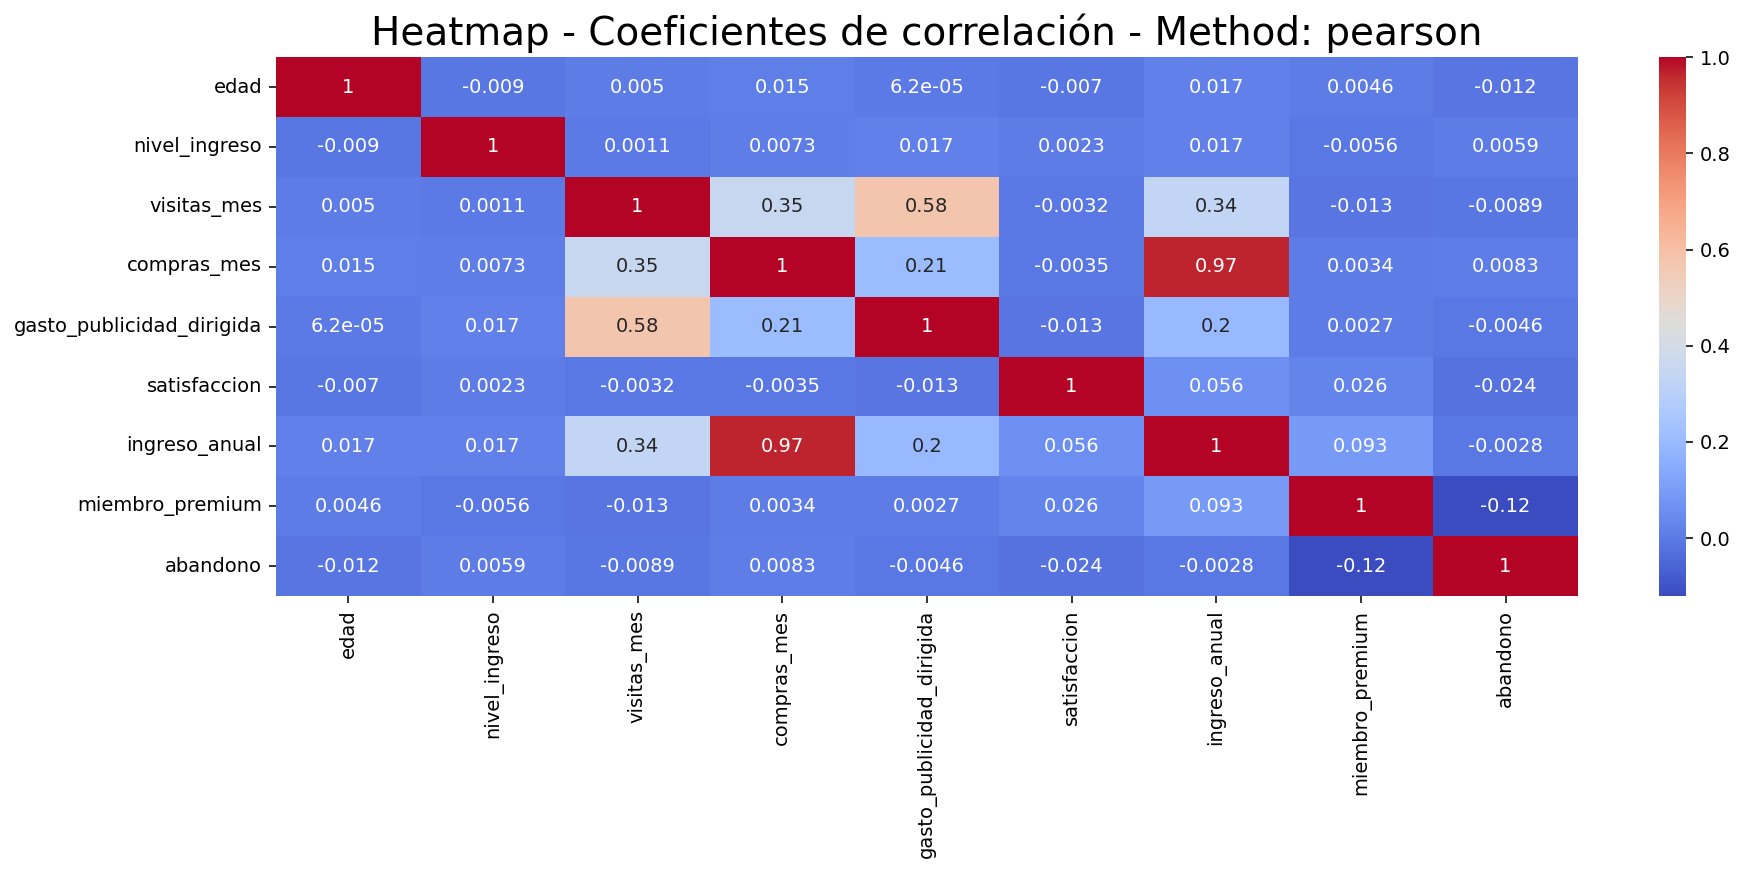


ANÁLISIS DE CORRELACIÓN. Variables numérica-numérica
----------------------------------------------------------
MATRIZ DE CORRELACIONES - Method: spearman 


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual,miembro_premium,abandono
edad,1.000000,-0.007775,0.005205,0.015630,0.002869,-0.007590,0.016097,0.003844,-0.010795
nivel_ingreso,-0.007775,1.000000,0.001420,0.009004,0.015393,0.005243,0.025017,-0.003687,0.005394
visitas_mes,0.005205,0.001420,1.000000,0.332943,0.559267,-0.001305,0.320954,-0.009092,-0.010318
compras_mes,0.015630,0.009004,0.332943,1.000000,0.192511,-0.002006,0.967482,0.007360,0.010395
gasto_publicidad_dirigida,0.002869,0.015393,0.559267,0.192511,1.000000,-0.012612,0.184999,0.005324,-0.004887
satisfaccion,-0.007590,0.005243,-0.001305,-0.002006,-0.012612,1.000000,0.060834,0.022199,-0.025320
ingreso_anual,0.016097,0.025017,0.320954,0.967482,0.184999,0.060834,1.000000,0.091883,0.000655
miembro_premium,0.003844,-0.003687,-0.009092,0.007360,0.005324,0.022199,0.091883,1.000000,-0.120488
abandono,-0.010795,0.005394,-0.010318,0.010395,-0.004887,-0.025320,0.000655,-0.120488,1.000000


----------------------------------------------------------


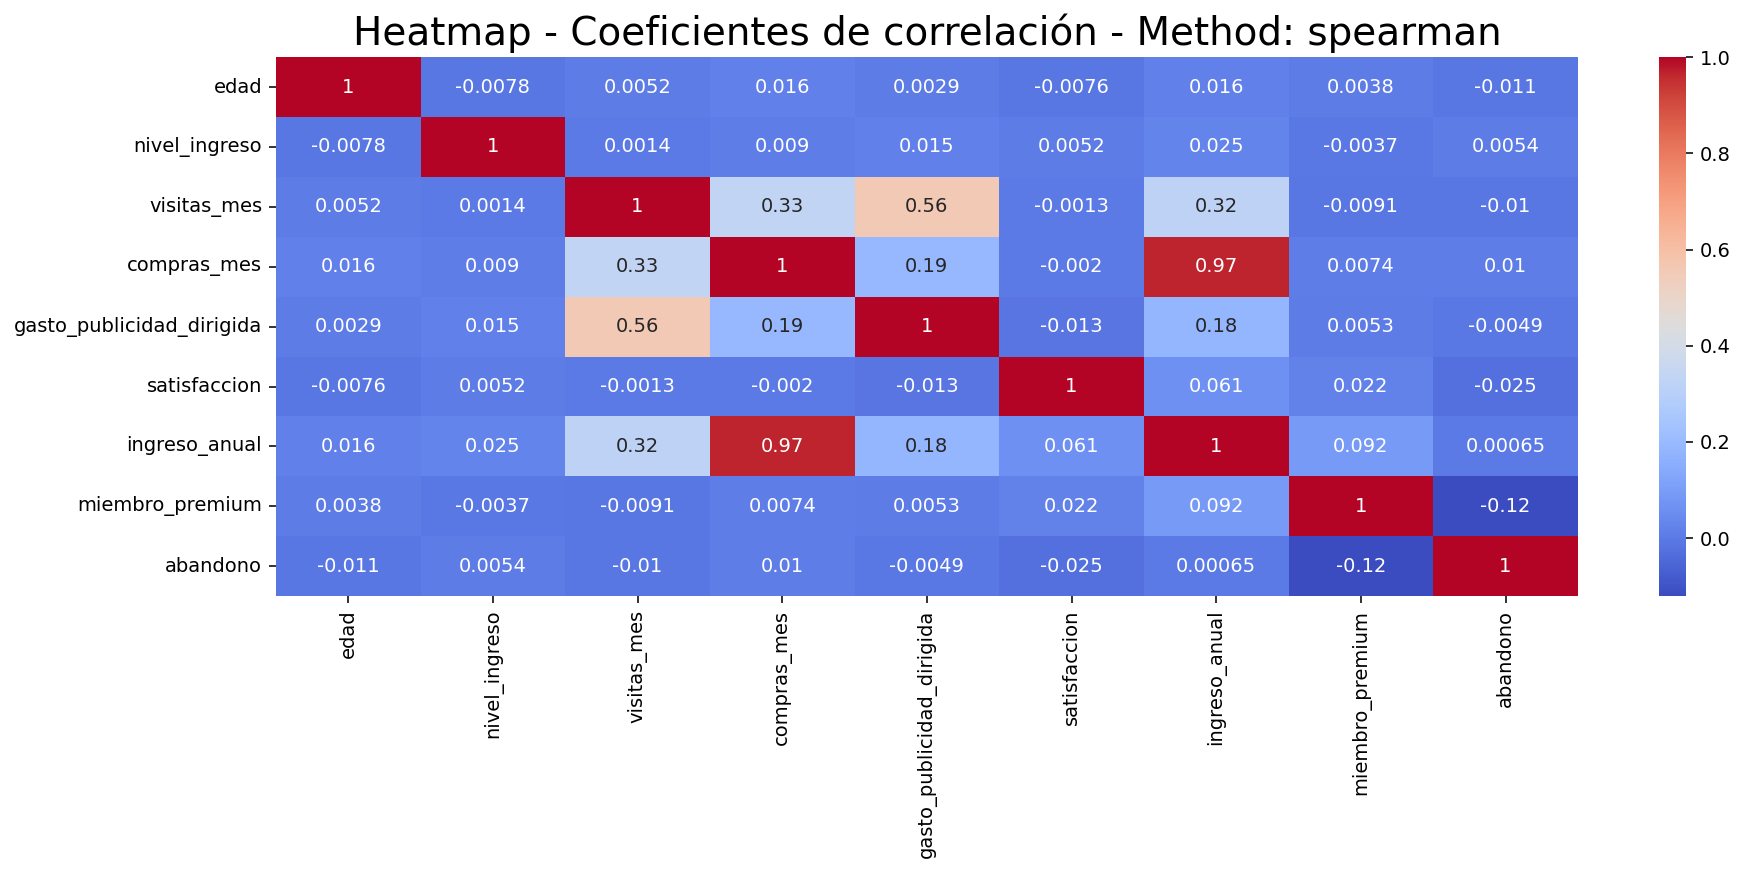

In [140]:
corr_analysis_num(dfc, col_num + col_bool, corr_method = 'pearson')
print()
corr_analysis_num(dfc, col_num + col_bool, corr_method = 'spearman')

### Heatmap

**Heatmap - PEARSON**
- `visitas_mes` y `gasto_publicidad_dirigida` r = 0.58, que sugiere una relación moderada-alta: a más visitas, más inversión publicitaria dirigida al usuario.
- `visitas_mes` y `compras_mes` r = 0.35 relación moderada.
- `compras_mes` y `gasto_publicidad_dirigida` r = 0.21 relación baja - moderada.
- `miembro_premium` y `abandono` r = -0.12; Presentan una relación inversa moderada, coherente con lo observado en el análisis exploratorio.
- `ingreso_anual` y `compras_mes` r = 0.97; Indica que el ingreso anual generado está casi completamente determinado por el número de compras mensuales.
- `ingreso_anual` y `visitas_mes` r = 0.34; relación moderada.
- `ingreso_anual` y `gasto_publicidad_dirigida` r = 0.20; relación baja - moderada.

**Heatmap - SPEARMAN**

Los resultados son muy consistentes con Pearson, lo que sugiere que las relaciones no dependen de supuestos de linealidad ni son artefactos de outliers.

Reafirmando que no existe relación lineal ni monotónica entre ambas.

### Scatterplot general

Se recomienda **no** incluir el Pairplot o Scatterplot general y sustituirlo por scatterplots individuales enfocados en los pares con correlación relevante, particularmente `compras_mes` vs `ingreso_anual` y `visitas_mes` vs `gasto_publicidad_dirigida`.

Esos dos gráficos aislados comunicarán los hallazgos con mucha más claridad que la matriz completa.



### Scatterplot para pares clave

In [169]:
def scatterplot_num(data, col1, col2):

  print("\n")
  plt.figure(figsize = (8,4), dpi = 100)
  sns.scatterplot(
      data = data,
      x=col1,
      y=col2,
      alpha = 0.5
  )

  sns.regplot(data=data, x=col1, y=col2,
              scatter=False, color='blue') # Línea de tendencia

  plt.title(f"Scatterplot - {col1} x {col2}", fontsize = 18)
  plt.savefig(f"Scatterplot - {col1} x {col2}.png",dpi = 100)
  plt.show()

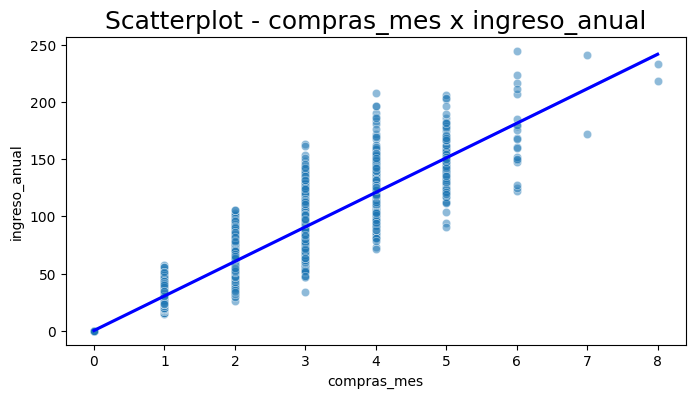

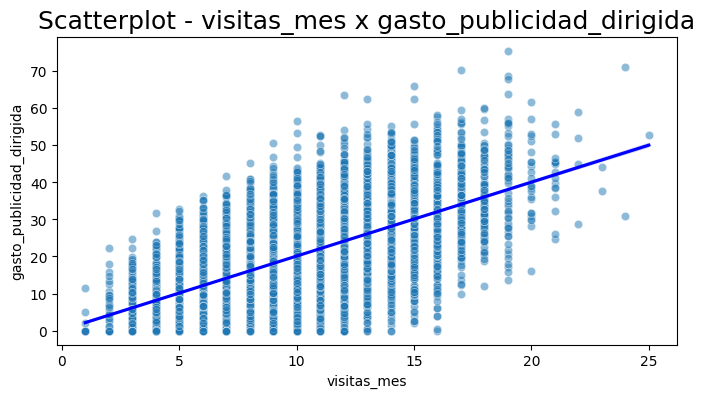

In [170]:
# Visualizar pares de variables con relaciones moderadas o fuertes
scatterplot_num(dfc, 'compras_mes', 'ingreso_anual')
scatterplot_num(dfc, 'visitas_mes', 'gasto_publicidad_dirigida')

**`compras_mes` vs `ingreso_anual`**
- Dirección: positiva y muy clara.
- Dispersión: baja-media. Dentro de cada columna discreta de `compras_mes` los puntos se concentran en un rango acotado de `ingreso_anual`, con muy poca variabilidad relativa.
- Outliers: presentes pero moderados. En `compras_mes` = 6 aparece un valor cercano a 245, que es el máximo del dataset. No son outliers extremos ni suficientes para distorsionar la tendencia general.
- Colinealidad: esta es la relación que más preocupa en ese sentido. Con r = 0.97, `compras_mes` e `ingreso_anual` son prácticamente la misma señal escalada. En cualquier modelo multivariado ambas no deberían entrar simultáneamente como predictores independientes.

---

**`visitas_mes` vs `gasto_publicidad_dirigida`**
- Dirección: positiva pero con mucho ruido. La línea de tendencia sube de izquierda a derecha, confirmando r = 0.58, pero la relación dista de ser determinista.
- Dispersión: alta. En cada valor de `visitas_mes` el rango de `gasto_publicidad_dirigida` es muy amplio, desde valores cercanos a 0 hasta 60-70. Esto indica que las visitas explican solo una parte de la inversión publicitaria; otros factores no capturados en el dataset también influyen.
- Outliers: algunos puntos aislados en la zona alta del eje Y (valores de gasto ~70-75) para niveles medios de visitas (10-20), pero sin alejarse dramáticamente de la nube general. No representan un problema analítico relevante.
- Colinealidad: no aplica directamente aquí ya que ninguna de las dos es la variable objetivo. Sin embargo, dado que `visitas_mes` correlaciona tanto con `gasto_publicidad_dirigida` (0.58) como con ingreso_anual (0.34), y que `gasto_publicidad_dirigida` también correlaciona con ingreso_anual (0.20), existe una cadena de asociación indirecta.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [162]:
def corr_analysis_relevantes(data, col1, col2, corr_method = 'pearson'):
  # Calcular correlación
  corr_uniq = data[col1].corr(data[col2], method = corr_method)
  print("\n----------------------------------------------------------")
  print(f"Coeficiente de {corr_method} - {col1} x {col2}")
  display(corr_uniq)

In [164]:
# Calcular correlación entre variables relevantes
corr_analysis_relevantes(dfc, 'compras_mes', 'ingreso_anual', corr_method = 'spearman')
corr_analysis_relevantes(dfc, 'visitas_mes', 'gasto_publicidad_dirigida', corr_method = 'pearson')


----------------------------------------------------------
Coeficiente de spearman - compras_mes x ingreso_anual


np.float64(0.967482492032673)


----------------------------------------------------------
Coeficiente de pearson - visitas_mes x gasto_publicidad_dirigida


np.float64(0.5789472719412829)

**`compras_mes` vs `ingreso_anual`**
- Por **Spearman** es apropiado por que el scatterplot muestra bandas y no continuidad.
- ρ **Spearman** = 0.9674 Dirección positiva, magnitud muy alta. La relación es casi determinista: cada compra adicional agrega un monto de ingreso prácticamente constante. Esto también levanta una señal de posible colinealidad estructural: `ingreso_anual` podría estar siendo calculado directamente a partir de `compras_mes` en el origen de los datos, lo que explicaría una correlación tan cercana a 1.

**`visitas_mes` vs `gasto_publicidad_dirigida`**
-  r **Pearson** = 0.5789, dirección positiva, magnitud moderada. La relación existe pero es ruidosa, como confirma el scatterplot. Spearman = 0.559 es ligeramente menor, lo que sugiere que algunos valores extremos de gasto inflan marginalmente el coeficiente lineal.
- Sin colinealidad problemática con la variable objetivo.

### Punto-biserial

In [177]:
def biserial_analysis(data, col1, col2):
  print("\n")
  plt.figure(figsize = (6,5))

  sns.barplot(
      data = data,
      x = col1,
      y = col2,
      estimator = "mean",
      palette = 'bright',
      edgecolor = 'black',
      errorbar = None
  )

  plt.title(f"Biserial - {col1} x {col2}", fontsize = 18)
  plt.savefig(f"Biserial - {col1} x {col2}.png",dpi = 80)
  plt.show()

/tmp/ipykernel_919/669266146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


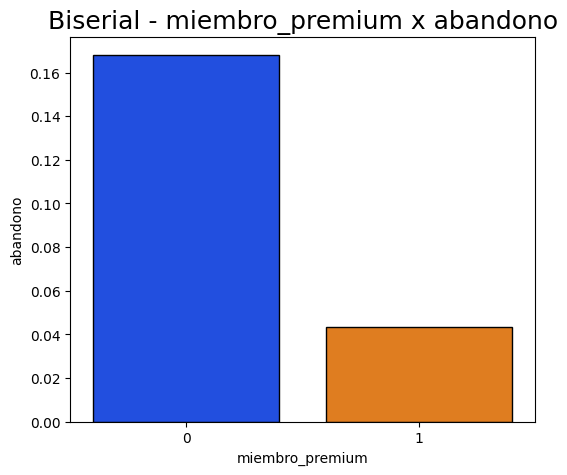

SignificanceResult(statistic=np.float64(-0.12048783398715407), pvalue=np.float64(1.2730798507365287e-49))

/tmp/ipykernel_919/669266146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


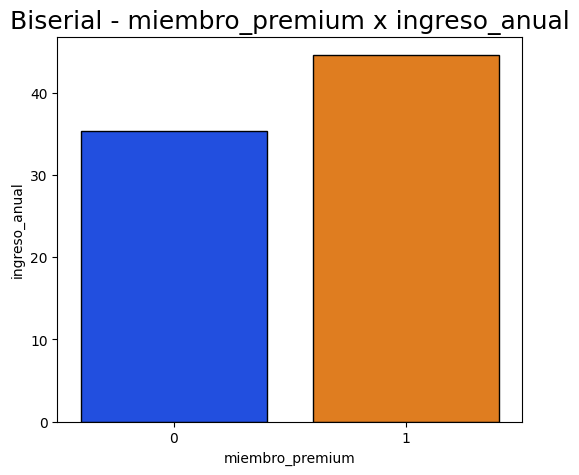

SignificanceResult(statistic=np.float64(0.0930994396198017), pvalue=np.float64(3.0943076155263697e-30))

In [181]:
biserial_analysis(dfc, 'miembro_premium', 'abandono')
premium_vs_abandono = pointbiserialr(dfc['miembro_premium'], dfc['abandono'])
display(premium_vs_abandono)
print()
biserial_analysis(dfc, 'miembro_premium', 'ingreso_anual')
premium_vs_ingreso_anual = pointbiserialr(dfc['miembro_premium'], dfc['ingreso_anual'])
display(premium_vs_ingreso_anual)

**`miembro_premium` x `abandono`**
- Los usuarios no premium (0) tienen una tasa de abandono ~0.17
- Los usuarios premium (1) tienen una tasa de abandono ~0.04
- Dirección negativa:  A medida que miembro_premium pasa de 0 a 1, el abandono disminuye.
- Coeficiente: -0.12 baja
- Ser premium reduce la probabilidad de abandono, pero:
- - No es un driver dominante

**`miembro_premium` x `ingreso_anual`**
- Los usuarios no premium: ingreso promedio ~35
- Los usuarios premium: ingreso promedio ~44
- Dirección positiva: Los usuarios premium tienden a tener mayor ingreso
- Coeficiente: 0.093 baja
- Personas con mayor ingreso → más probabilidad de ser premium, pero la relación es muy débil.

### V de Cramér

In [188]:
# Función para calcular V de Cramér
def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    return v

In [189]:
# Aplicar V de Cramér en variables relevantes
coef_cramer = cramer_v(dfc, "tipo_dispositivo", "region")

print("\nCorrelación entre: tipo_dispositivo y region")
print(f"V de Cramér: {coef_cramer :.3f}")


Correlación entre: tipo_dispositivo y region
V de Cramér: 0.012


**V de Cramér**

0.012 es muy débil o casi nulo.

Por tanto, el tipo de dispositivo es independiente de la región.

## Sección 5 - Interpretación de resultados para el negocio

### Monetización (Crítico)
  
**Evidencia numérica:**
- Correlación Pearson = 0.97
- Correlación Spearman = 0.967
- 25% de clientes generan 0 ingresos

**Interpretación no causal**  
- Existe una relación positiva extremadamente alta entre compras_mes e ingreso_anual. En la práctica, el ingreso está casi completamente explicado por la cantidad de compras.

**No podemos afirmar**  
- Que aumentar compras cause mayor ingreso (puede ser una construcción del dato o una dependencia estructural).
- Que esta relación sea accionable sin segmentación.

**Implicación de negocio**

El problema NO es monetización, es activación:

Hay un segmento grande de clientes que no compra (≈25%).

Prioridad: mover clientes de 0 a 1 (compra).

---

### Suscripciones Premium (Retención)

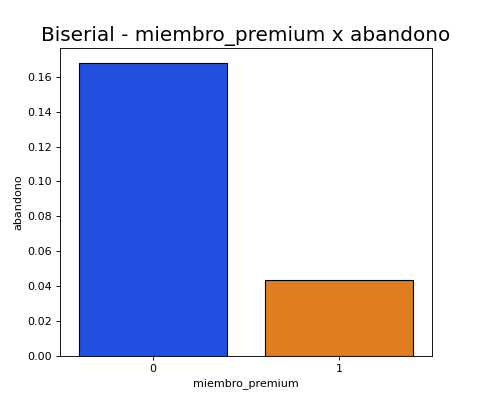

**Evidencia numérica:**
- Correlación: -0.12 (negativa baja)
- Retención premium: 95.6%
- Retención no premium: 83.2%

**Interpretación no causal**  
- Ser premium está asociado con menor abandono, aunque la magnitud estadística es baja.

**No podemos afirmar**  
- Que hacer premium a un usuario reduzca su churn directamente
- Que premium sea el driver principal de retención

**Implicación de negocio**  

Premium funciona como indicador de valor, no como palanca principal

- Estrategia: usar premium como señal para identificar clientes valiosos
- No depender solo de premium para retención

---


### Publicidad dirigida

**Evidencia numérica:**
- Correlación: 0.58 (moderada-alta)

**Interpretación no causal**  
- Usuarios con más visitas tienden a recibir más inversión publicitaria, pero con alta dispersión.

**No podemos afirmar**  
- Que más visitas causen mayor inversión
- Que la inversión esté optimizada

**Implicación de negocio**  

Hay señales de segmentación publicitaria, pero no eficiente

- Existe mucho ruido → inversión no completamente explicada
- Oportunidad: mejorar targeting (modelos predictivos)

---


### Segmentación natural del negocio (hallazgo estructural)

**Evidencia numérica:**
- ~25% sin compras ni ingresos
- Compras promedio: 1.2/mes (muy bajo)

**Interpretación no causal**  
- Clientes activos (compran)
- Clientes inactivos (no compran)

**No podemos afirmar**  
- Qué causa que un cliente esté en cada grupo
- Que ambos segmentos respondan igual a estrategias

**Implicación de negocio**  

Este es el principal eje de segmentación

- Todas las estrategias deben separarse por:
- - activos vs inactivos
- Mezclarlos diluye insights

---

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Posible colinealidad estructural (compras vs ingreso)
- Alta proporción de ceros distorsiona análisis

### **Próximos pasos**

1. Segmentación crítica
- Opción 1: Clientes con compras vs sin compras
- Opción 2: Clientes por nivel de visitas (alto vs bajo)

2. Modelado de conversión
- Opción 1: Modelo para predecir primera compra
- Opción 2: Modelo de propensión a abandono

3. Optimización de marketing
- Opción 1: Reasignar gasto hacia usuarios con mayor probabilidad de compra